## Hovmollers comparison

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
from matplotlib.colors import TwoSlopeNorm 
import matplotlib.colors as mcolors

### Functions

In [2]:
## kml to struct
def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [3]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

## Lon and lat for the whole dataset
lat = np.linspace(-33.0, 10.03286, 542).reshape(542, 1)  # Reshape to match eta_rho
lon = np.linspace(-118.9083, -68.90833, 602).reshape(1, 602)  # Reshape to match xi_rho

lats, lons = np.meshgrid(lat.flatten(), lon.flatten(), indexing="ij")

LON=lons
LAT=lats
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

### Dataset

In [4]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
ds

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lon_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lon_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
    lat_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
  * time        (time) float32 4B 1.339e+06
Dimensions without coordinates: auxil
Data variables: (12/54)
    spherical   |S1 1B ...
    xl          float64 8B ...
    el          float64 8B ...
    Vtransform  float64 8B ...
    sc_r        (s_rho) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
    sc_w        (s_w) float64 264B dask.array<chunksize=(33,), meta=np.ndarray>
    ...          ...
    swflux      (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    radsw       (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_rlw   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_lat   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_sen   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    hel         (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
Attributes: (12/57)
    type:           ROMS restart file
    title:          Peru UW Interannual Run
    date:           
    rst_file:       croco_rst.nc
    his_file:       croco_his.nc
    avg_file:       croco_avg.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL PERU_UW MPI OBC_WEST OBC_NORTH OBC_SOUTH BIOLOGY...

In [5]:
time = pd.date_range(start='1980-01', end='2016-01', freq='M')
#----- CROCO wmld
WMLD_data = loadmat("../../NHCS/Processed/WMLD_MLD.mat")

#-----mld
MLD = loadmat("../../NHCS/Processed/WMLD_MLD.mat")

#----- CUTI
CUTI_data = loadmat("../../NHCS/Processed/CUTI.mat")

#----- AV
AV_data = loadmat("../../NHCS/Processed/AV.mat")

/tmp/ipykernel_1216021/589681338.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='1980-01', end='2016-01', freq='M')


In [6]:
##mask
mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)
expanded_mask = np.tile(mask_nan[np.newaxis, :, :], (432, 1, 1))
print(expanded_mask.shape)

(432, 542, 602)


In [7]:
UI_ds = xr.Dataset(
    data_vars={
        'MLD': (("time", "lat","lon"), MLD['MLD'].transpose(2, 1, 0)*expanded_mask),
        'WMLD': (("time", "lat","lon"), WMLD_data['WMLD'].transpose(2, 0, 1)*expanded_mask*86400), #m/day),
        # 'Ekman_pump': (("time", "lat","lon"), Ek_pump.transpose(2, 1, 0)),
        # 'Ekman_transport':(("time", "lat","lon"), Ek_tr.transpose(2, 1, 0)),
        'AV': (("time", "lat","lon"), AV_data['W_analytical'].transpose(2, 1, 0)*expanded_mask*86400), #m/day,
        # 'CUpwelling':(('time','lat','lon'),Coastal_up['WcMean'].transpose(2, 1, 0)),
        # 'HUI': (("time", "lat","lon"), HUI_data['HUI'].transpose(2, 1, 0)),
        'CUTI': (("time", "lat","lon"), CUTI_data['CUTI'].transpose(2, 1, 0) *-1), #m2/s
        # 'BEUTI': (("time", "lat","lon"), BEUTI_data['BEUTI'].transpose(2, 1, 0) *-1),
        # 'BUI': (("time", "lat","lon"), BUI_data['BUI'].transpose(2, 1, 0)),        
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

UI_ds
# mask_rho = ds.mask_rho.values 
# mask_nan = np.where(mask_rho, 1, np.nan)

# UI_ds['WMLD'] = UI_ds.WMLD*mask_nan
# UI_ds['BUI'] = UI_ds.BUI*mask_nan

<xarray.Dataset> Size: 4GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB 0.9402 0.9402 1.335 ... nan nan nan
    WMLD     (time, lat, lon) float64 1GB 0.003986 0.003986 0.02448 ... nan nan
    AV       (time, lat, lon) float64 1GB 0.02743 0.04068 0.06235 ... nan nan
    CUTI     (time, lat, lon) float32 564MB -0.09788 -0.102 -0.1076 ... nan nan

In [8]:
UI_mmean = UI_ds.groupby('time.month').mean(dim='time')
UI_anomaly = UI_ds.groupby('time.month') - UI_mmean

In [9]:
in_band = UI_anomaly*inshore_mask
band = in_band.sel(lat=slice(-20,0)).mean(dim='lon',skipna=True)
band

<xarray.Dataset> Size: 3MB
Dimensions:  (lat: 245, time: 432)
Coordinates:
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -0.2494 -0.1661 -0.08278
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
    month    (time) int64 3kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    MLD      (time, lat) float64 847kB 0.2238 0.3319 0.5429 ... 0.3986 0.4315
    WMLD     (time, lat) float64 847kB -0.0209 0.06117 ... 0.6723 0.8745
    AV       (time, lat) float64 847kB -0.01086 0.003186 ... -13.33 -21.2
    CUTI     (time, lat) float64 847kB -0.05003 -0.04123 ... 9.784 13.33

In [10]:
print(band)

<xarray.Dataset> Size: 3MB
Dimensions:  (lat: 245, time: 432)
Coordinates:
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -0.2494 -0.1661 -0.08278
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
    month    (time) int64 3kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    MLD      (time, lat) float64 847kB 0.2238 0.3319 0.5429 ... 0.3986 0.4315
    WMLD     (time, lat) float64 847kB -0.0209 0.06117 ... 0.6723 0.8745
    AV       (time, lat) float64 847kB -0.01086 0.003186 ... -13.33 -21.2
    CUTI     (time, lat) float64 847kB -0.05003 -0.04123 ... 9.784 13.33


### ENSO

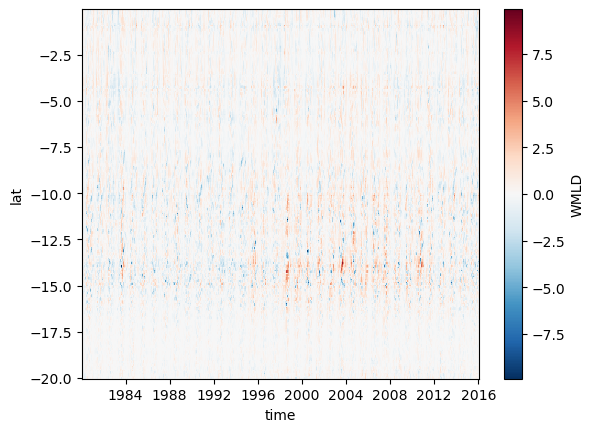

In [11]:
band.WMLD.plot(x='time')

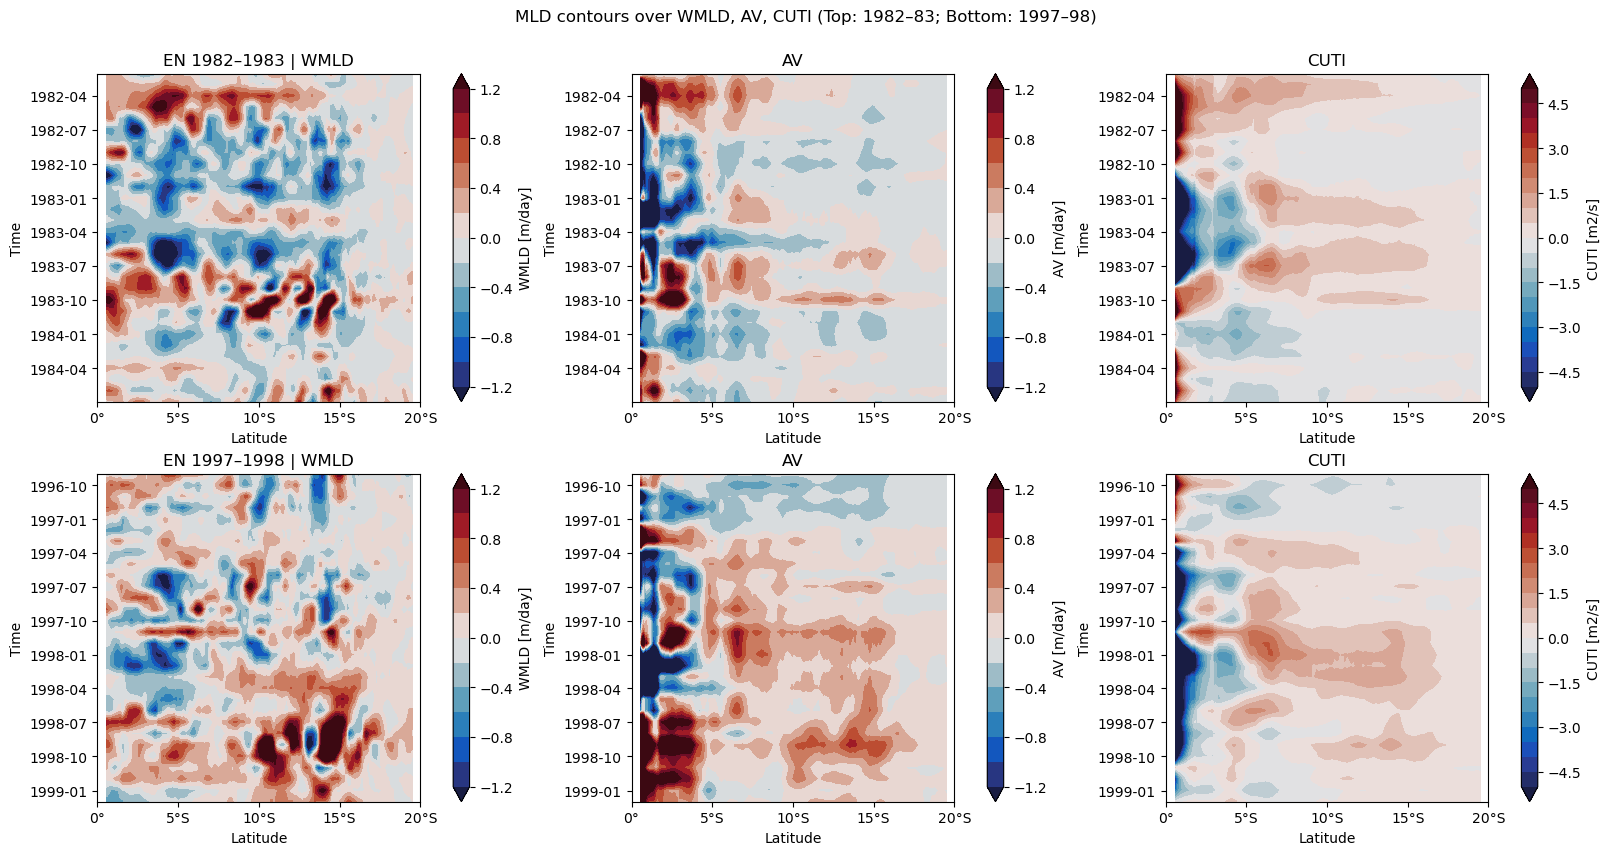

In [27]:
# Norms/levels
levels_MLD = np.arange(-30, 30+5, 5)
levels_WMLD = np.arange(-1.2, 1.2+0.2, 0.2)

colors = ['green' if x < 0 else 'black' for x in levels_WMLD]
cmap_div = mcolors.ListedColormap(colors)

norm_MLD = TwoSlopeNorm(vmin=-30, vcenter=0, vmax=30)
levels_MLD = np.arange(-30, 30+5, 5)

norm_WMLD = TwoSlopeNorm(vmin=-1.2, vcenter=0, vmax=1.2)
levels_WMLD = np.arange(-1.2, 1.2+0.2, 0.2)

# Example norms/levels for AV and CUTI (adjust as needed)
norm_AV   = TwoSlopeNorm(vmin=-1.2, vcenter=0, vmax=1.2)
levels_AV = np.arange(-1.2, 1.2+0.2, 0.2)

norm_CUTI   = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
levels_CUTI = np.linspace(-5, 5, 21)

# Prep data once
band_roll = band.rolling(lat=13, center=True).mean()
ds_8283 = band_roll.sel(time=slice("1982-01", "1984-06"))
ds_9798 = band_roll.sel(time=slice("1996-08", "1999-01"))

# Figure: 2 rows (periods) × 3 cols (variables)
fig, ax = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)

def format_lat_ticks(ax_):
    xt = ax_.get_xticks()
    labels = [f"{-x:.0f}°S" if x < 0 else (f"{x:.0f}°N" if x > 0 else "0°") for x in xt]
    ax_.set_xticks(xt)
    ax_.set_xticklabels(labels)

def plot_row(ds_sel, row_title, row_idx):
    # Column 0: WMLD with MLD contours
    cf = ds_sel.WMLD.plot.contourf(
        ax=ax[row_idx, 0], y='time', x='lat',
        cmap=cm.balance, norm=norm_WMLD, levels=levels_WMLD, add_colorbar=True
    )
    cf.colorbar.ax.set_ylabel('WMLD [m/day]')
    # cc = ds_sel.MLD.plot.contour(
    #     ax=ax[row_idx, 0], y='time', x='lat',
    #     levels=levels_MLD, colors=cmap_div, linestyles='--', linewidths=0.7, add_colorbar=False
    # )
    # ax[row_idx, 0].clabel(cc, inline=True, fontsize=7, fmt="%.0f")

    # Column 1: AV with MLD contours
    cf = ds_sel.AV.plot.contourf(
        ax=ax[row_idx, 1], y='time', x='lat',
        cmap=cm.balance, norm=norm_AV, levels=levels_AV, add_colorbar=True
    )
    cf.colorbar.ax.set_ylabel('AV [m/day]')
    # cc = ds_sel.MLD.plot.contour(
    #     ax=ax[row_idx, 1], y='time', x='lat',
    #     levels=levels_MLD, colors=cmap_div, linestyles='--', linewidths=0.7, add_colorbar=False
    # )
    # ax[row_idx, 1].clabel(cc, inline=True, fontsize=7, fmt="%.0f")

    # Column 2: CUTI with MLD contours
    cf = ds_sel.CUTI.plot.contourf(
        ax=ax[row_idx, 2], y='time', x='lat',
        cmap=cm.balance, norm=norm_CUTI, levels=levels_CUTI, add_colorbar=True
    )
    cf.colorbar.ax.set_ylabel('CUTI [m2/s]')
    # cc = ds_sel.MLD.plot.contour(
    #     ax=ax[row_idx, 2], y='time', x='lat',
    #     levels=levels_MLD, colors=cmap_div, linestyles='--', linewidths=0.7, add_colorbar=False
    # )
    # ax[row_idx, 2].clabel(cc, inline=True, fontsize=7, fmt="%.0f")

    # Cosmetics per row
    for j in range(3):
        ax[row_idx, j].invert_yaxis()
        ax[row_idx, j].invert_xaxis()
        format_lat_ticks(ax[row_idx, j])
        ax[row_idx, j].set_xlabel('Latitude')
        ax[row_idx, j].set_ylabel('Time')
        # Titles: left panel shows period; others show var name
        if j == 0:
            ax[row_idx, j].set_title(f"{row_title} | WMLD")
        elif j == 1:
            ax[row_idx, j].set_title("AV")
        else:
            ax[row_idx, j].set_title("CUTI")

# Top row: 1982–1983
plot_row(ds_8283, "EN 1982–1983", row_idx=0)

# Bottom row: 1997–1998
plot_row(ds_9798, "EN 1997–1998", row_idx=1)

fig.suptitle("MLD contours over WMLD, AV, CUTI (Top: 1982–83; Bottom: 1997–98)", y=1.05)
plt.savefig('Figures/UP_Region_hovmoller_Paper'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')

plt.show()